#TASK 1:  DATASET ANALYSIS


# **IMPORTING ESSENTIAL LIBRARIES**



In [80]:
!python --version

Python 3.12.13


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from collections import defaultdict
nlp = spacy.load("en_core_web_sm")
import re
from collections import Counter
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import json


# **IMPORTING DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/SafePath/master_clauses.csv")

# **EXPLORATORY DATA ANALYSIS**

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe(include ="all")

In [ ]:
df.shape

## Each Row Represents a single contract and we have about 510 contracts (entries) and 83 columns. So conceptually there are 510 legal agreements and each agreement checked against 41 legal risk categories

In [ ]:
for i, col in enumerate  (df.columns):
    print(f"{i}: {col}")

##To see the Column name clearly we had to print and index for each column to see the printed column names clearly.

In [ ]:
df.columns.unique()

In [ ]:
unique_counts = df.nunique().reset_index()
unique_counts.columns = ['Column', 'Unique values']
print(unique_counts)

##We checked for unique entries in the columns, and noticed that the dataset was in a WIDE format. and It is structured like this:

| Column Type           | Meaning                |
| --------------------- | ---------------------- |
| Metadata Columns      | Contract identity info |
| Clause Columns        | Extracted clause text  |
| Clause-Answer Columns | Yes/No label           |

-`Metadata Columns` are the context that describe the contract. For example: `Filename`, `Document Name`, `Parties`, `Agreement Date`, `Effective Date`, `Expiration Date`, etc.


-`Clause Columns` (AKA Risk Indicators) are the legal risk signals. Example of these columns include: `Non-Compete`, `Exclusivity`, `Termination For Convenience`, `Uncapped Liability`, `Cap On Liability`, `Audit Rights`, `Ip Ownership Assignment`, `Liquidated Damages`, `Insurance,Third Party Beneficiary`, etc. And their corresponding Extracted clause text columns (Clause-Answer Columns) contains the actual indicators for example the preceding `Non-Compete-Answer`, `Exclusivity-Answer`, `Termination For Convenience-Answer`, and so on (if present), Empty list [] if not present. Hence `Clause Columns` is like the Risk label for the column carry indicator `Clause-Answer Columns`.



-`Clause-Answer Columns`: Like we have talked about, for every clause column, there is a matching `Clause Name - Answer`, and this is what we will primarily use for risk mapping. For example:`Non-Compete` → `Non-Compete-Answer`, `Cap On Liability → Cap On Liability-Answer, etc.  And the Values` are:`Yes` or `No`; telling us whether the clause exists in that contract or not.

## IDENTIFY CLAUSE-ANSWER COLUMNS

In [ ]:
#All clause presence columns end with "-Answer"
answer_cols = [col for col in df.columns if col.endswith("-Answer")]
answer_cols

## TOTAL NUMBER OF CLAUSE-ANSWER COLUMNS

In [ ]:
print("Total Clause Types:", len(answer_cols))

## FREQUENCY CALCULATION

In [ ]:
clause_frequency = {}

for col in answer_cols:
    clause_name = col.replace("-Answer", "")
    yes_count = (df[col] == "Yes").sum()
    clause_frequency[clause_name] = yes_count

In [ ]:
# Convert to DataFrame
freq_df = pd.DataFrame.from_dict(
    clause_frequency,
    orient="index",
    columns=["Contract_Count"]
)

In [ ]:
freq_df

## TOP **10 MOST FREQUENT** CLAUSES BY TOTAL COUNT

In [ ]:
# Sort descending
freq_df = freq_df.sort_values(
    by="Contract_Count",
    ascending=False
)

print(freq_df.head(10))

## TOP **10 MOST FREQUENT** CLAUSES IN %

In [ ]:
total_contracts = len(df)

freq_df["Percentage"] = (
    freq_df["Contract_Count"] / total_contracts
) * 100

print(freq_df.head(10))


# FEATURE ENGINEERING

Next we define the risk domain by grouping all legal clauses into broader conceptual risk domains.

In [ ]:
risk_domain_mapping = {
    "Financial Risk": [
        "Uncapped Liability",
        "Cap On Liability",
        "Liquidated Damages",
        "Minimum Commitment",
        "Revenue/Profit Sharing",
        "Price Restrictions",
        "Most Favored Nation",
        "Volume Restriction"
    ],

    "Operational Risk": [
        "Termination For Convenience",
        "Post-Termination Services",
        "Audit Rights",
        "Anti-Assignment",
        "Change Of Control",
        "Renewal Term"
    ],

    "Strategic Restriction Risk": [
        "Non-Compete",
        "Exclusivity",
        "No-Solicit Of Employees",
        "No-Solicit Of Customers",
        "Competitive Restriction Exception",
        "Rofr/Rofo/Rofn"
    ],

    "Intellectual Property Risk": [
        "Ip Ownership Assignment",
        "Joint Ip Ownership",
        "License Grant",
        "Non-Transferable License",
        "Irrevocable Or Perpetual License",
        "Source Code Escrow",
          "Affiliate License-Licensor",
        "Affiliate License-Licensee",
        "Unlimited/All-You-Can-Eat-License"
    ],

    "Compliance / Legal Risk": [
        "Insurance",
        "Covenant Not To Sue",
        "Third Party Beneficiary",
        "Warranty Duration",
        "Non-Disparagement",
        "Governing Law"

    ]
}


CUAD clause labels are highly specific legal terms. So to make the system interpretable and useful for SMEs, clauses are grouped into higher-level risk categories such as `Financial Risk`, `Operational Risk`, `Strategic Risk`, `Intellectual Property Risk`, and `Compliance/Legal Risk`. This step represents the beginning of feature engineering, transforming raw legal categories into semantic risk features. This is essential because every clause should belong to one domain to ensure complete ontology coverage.

## DEFINING THE CLAUSE SEVERITY

In [ ]:
severity_mapping = {

    # HIGH RISK (major SME exposure)
    "Uncapped Liability": "High",
    "Minimum Commitment": "High",
    "Termination For Convenience": "High",
    "Exclusivity": "High",
    "Non-Compete": "High",
    "Ip Ownership Assignment": "High",
    "Liquidated Damages": "High",

    # MEDIUM RISK (important but context-dependent)
    "Audit Rights": "Medium",
    "Revenue/Profit Sharing": "Medium",
    "Anti-Assignment": "Medium",
    "Cap On Liability": "Medium",
    "Volume Restriction": "Medium",
    "Most Favored Nation": "Medium",
    "Rofr/Rofo/Rofn": "Medium",
    "Affiliate License-Licensor": "Medium",
    "Affiliate License-Licensee": "Medium",
    "Change Of Control": "Medium",
    "No-Solicit Of Employees": "Medium",
    "No-Solicit Of Customers": "Medium",
    "Competitive Restriction Exception": "Medium",
    "Post-Termination Services": "Medium",
    "Price Restrictions": "Medium",
    "Irrevocable Or Perpetual License": "Medium",
    "Source Code Escrow": "Medium",

    # LOW RISK (legal structure / informational)
    "Warranty Duration": "Low",
    "Non-Disparagement": "Low",
    "Unlimited/All-You-Can-Eat-License": "Low",
    "Renewal Term": "Low",
    "Notice Period To Terminate Renewal": "Low",
    "Governing Law": "Low",
    "Joint Ip Ownership": "Low",
    "License Grant": "Low",
    "Non-Transferable License": "Low",
    "Insurance": "Low",
    "Covenant Not To Sue": "Low",
    "Third Party Beneficiary": "Low"
}


We assigned an impact level (High/Medium/Low) to each clause because not all clauses pose equal risk to SMEs. Severity reflects potential financial, operational, legal, or strategic impact if the clause is unfavorable. This allows the system to prioritize warnings for users.

In [ ]:
severity_score_map = {
    "High": 3,
    "Medium": 2,
    "Low": 1
}


The Severity Score map converts qualitative severity labels into numeric values. This is important because numeric scores enable quantitative analysis such as:

    Risk Score = Frequency × Severity

This allows ranking clauses by overall risk importance,mapping High to 3,  Medium to 2 and Low to 1


## To add Severity to Frequency Table

In [ ]:
freq_df["Severity"] = freq_df.index.map(
    lambda x: severity_mapping.get(x, "Low")
)

The Purpose of adding severity to frequency table is to assigns a qualitative risk level (High/Medium/Low) to each clause using the predefined severity mapping.
To ensure that we use the map() to look up each clause in severity_mapping and use the get(x, "Low") to  ensure missing clauses default to Low.




In [ ]:
freq_df

,Contract_Count,Percentage,Severity
Anti-Assignment,374,73.333333,Medium
Cap On Liability,275,53.921569,Medium
License Grant,255,50.000000,Low
Audit Rights,214,41.960784,Medium
Termination For Convenience,183,35.882353,High
Post-Termination Services,182,35.686275,Medium
Exclusivity,180,35.294118,High
Insurance,167,32.745098,Low
Revenue/Profit Sharing,166,32.549020,Medium
Minimum Commitment,165,32.352941,High


##To add Numeric Scores

In [ ]:
freq_df["Severity_Score"] = freq_df["Severity"].map(
    severity_score_map
)

This converts qualitative severity labels into numbers because mathematical calculations require numeric values and we need  Severity score to compute the Risk Score

In [ ]:
freq_df

,Contract_Count,Percentage,Severity,Severity_Score
Anti-Assignment,374,73.333333,Medium,2
Cap On Liability,275,53.921569,Medium,2
License Grant,255,50.000000,Low,1
Audit Rights,214,41.960784,Medium,2
Termination For Convenience,183,35.882353,High,3
Post-Termination Services,182,35.686275,Medium,2
Exclusivity,180,35.294118,High,3
Insurance,167,32.745098,Low,1
Revenue/Profit Sharing,166,32.549020,Medium,2
Minimum Commitment,165,32.352941,High,3


##Calculate Risk Score

In [ ]:
freq_df["Risk_Score"] = (
    freq_df["Contract_Count"] *
    freq_df["Severity_Score"]
)


## Risk Score Formula:
     Risk Score = Contract_Count × Severity_Score

This combine clause prevalence and severity into one quantitative risk metric.
And Higher Score equals to clause that is both common and impactful.


In [ ]:
freq_df

,Contract_Count,Percentage,Severity,Severity_Score,Risk_Score
Anti-Assignment,374,73.333333,Medium,2,748
Cap On Liability,275,53.921569,Medium,2,550
License Grant,255,50.000000,Low,1,255
Audit Rights,214,41.960784,Medium,2,428
Termination For Convenience,183,35.882353,High,3,549
Post-Termination Services,182,35.686275,Medium,2,364
Exclusivity,180,35.294118,High,3,540
Insurance,167,32.745098,Low,1,167
Revenue/Profit Sharing,166,32.549020,Medium,2,332
Minimum Commitment,165,32.352941,High,3,495


## To generate Risk-Weighted Ranking

In [ ]:
risk_ranked_df = freq_df.sort_values(
    by="Risk_Score",
    ascending=False
)

Ranked clauses from highest to lowest risk priority by sorting dataframe by Risk_Score descending.

In [ ]:
risk_ranked_df.head(15)


,Contract_Count,Percentage,Severity,Severity_Score,Risk_Score
Anti-Assignment,374,73.333333,Medium,2,748
Cap On Liability,275,53.921569,Medium,2,550
Termination For Convenience,183,35.882353,High,3,549
Exclusivity,180,35.294118,High,3,540
Minimum Commitment,165,32.352941,High,3,495
Audit Rights,214,41.960784,Medium,2,428
Ip Ownership Assignment,124,24.313725,High,3,372
Post-Termination Services,182,35.686275,Medium,2,364
Non-Compete,119,23.333333,High,3,357
Uncapped Liability,111,21.764706,High,3,333


##Creating a Train / Test Split set

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    shuffle=True,
    stratify=df["Termination For Convenience-Answer"]
)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (357, 83)
Test size: (153, 83)


#TASK 2: SYSTEM EXECUTION

##Data Cleaning

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"[\[\]']", "", text)
    return text


We define this function to clean  Clause Text since most of our clause text samples are list-like strings.

##Clause Text Exploration

In [ ]:
clause = "Termination For Convenience"

examples = train_df[
    train_df[f"{clause}-Answer"] == "Yes"
][clause]

print(examples.head(10))


398    ["Upon the occurrence of any of the following,...
492    ['FUSION may terminate this Agreement by provi...
204    ['The Company reserves the right in its sole a...
325    ['At any time during a renewed term, this Agre...
464    ['Owner may terminate this Agreement at any ti...
272    ["With respect to Beacon Optofluidic Machines ...
178    ["Pretzel  Time  reserves  the right to  suspe...
358              ['Termination for Convenience. [***].']
236    ["Except as may be provided in any Schedule, M...
375    ['The Parties may terminate its performance of...
Name: Termination For Convenience, dtype: object


We started with ONE clause first, `Termination For Convenience`clause for Clause Text Exploration. Extract real corpus examples from the clause column and printed about 10 samples to see how they look like.

##Extract Lemmas Using SPACY (Rule Discovery)

In [ ]:
texts = [clean_text(t) for t in examples]

lemmas = []

for text in texts:
    doc = nlp(text)

    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        lemmas.append(token.lemma_.lower())


print(Counter(lemmas).most_common(20))

[('agreement', 183), ('notice', 168), ('terminate', 164), ('write', 139), ('day', 98), ('party', 92), (' ', 90), ('prior', 88), ('time', 79), ('shall', 60), ('termination', 56), ('provide', 53), ('date', 42), ('right', 41), ('term', 38), ('month', 37), ('give', 36), ('30', 34), ('reason', 29), ('company', 27)]


 We had to use spaCy to normalize legal language through lemmatization, identify common verbs and noun phrases and very importantly reveal recurring linguistic patterns in clauses. This is so important because these patterns would guide the regex rule design towards a deterministic rule-based detection approach.

##Extract Key Noun Phrases

In [ ]:
noun_phrases = []

for text in texts:
    doc = nlp(text)

    for chunk in doc.noun_chunks:
        noun_phrases.append(chunk.text.lower())

print(Counter(noun_phrases).most_common(20))


[('this agreement', 152), ('any time', 72), ('notice', 43), ('either party', 35), ('written notice', 28), ('the other party', 28), ('prior written notice', 25), ('cause', 24), ('the right', 21), ('any reason', 20), ('termination', 17), ('the effective date', 17), ('the company', 17), ('any', 16), ('section', 12), ('convenience', 11), ('thirty (30) days', 11), ('the agreement', 11), ('such termination', 11), ('*', 11)]


In [ ]:
# PHRASE FREQUENCY
phrase_freq = Counter(noun_phrases)

# REGEX GENERATION
TOP_N = 10

top_phrases = [
    p for p, c in phrase_freq.most_common(TOP_N)
]

ignore_phrases = [
    "this agreement",
    "the agreement",
    "section",
    "which"
]


top_phrases = [
    p for p, c in phrase_freq.most_common(30)
    if p not in ignore_phrases
][:10]


print(top_phrases)

['any time', 'notice', 'either party', 'written notice', 'the other party', 'prior written notice', 'cause', 'the right', 'any reason', 'termination']


##Extract Verb + Nearby Phrase

In [ ]:
verb_phrase_pairs = []

for text in texts:
    doc = nlp(text)

    for token in doc:

        # focus on verbs
        if token.pos_ == "VERB":

            # collect nearby noun chunks
            for chunk in doc.noun_chunks:

                # distance filter (same sentence area)
                if abs(token.i - chunk.root.i) < 6:

                    pair = (
                        token.lemma_.lower(),
                        chunk.text.lower()
                    )

                    verb_phrase_pairs.append(pair)


Legal clauses are often defined by actions (verbs) combined with contextual phrases. This step uses spaCy to identify verbs and nearby noun phrases to automatically suggest regex pattern structures. These patterns improve detection precision compared to standalone keywords.

##VERB–PHRASE FREQUENCY ANALYSIS

In [ ]:
pair_freq = Counter(verb_phrase_pairs)

print(pair_freq.most_common(20))


[(('terminate', 'this agreement'), 117), (('write', 'notice'), 35), (('terminate', 'either party'), 29), (('write', 'written notice'), 27), (('terminate', 'any time'), 26), (('write', 'prior written notice'), 25), (('write', 'the other party'), 21), (('terminate', 'the right'), 16), (('have', 'the right'), 16), (('write', 'any time'), 11), (('write', 'this agreement'), 9), (('terminate', 'cause'), 9), (('give', 'any time'), 9), (('write', 'sixty (60) days'), 9), (('write', 'thirty (30) days'), 8), (('write', 'ninety (90) days'), 8), (('give', 'this agreement'), 8), (('give', 'written notice'), 7), (('terminate', 'the agreement'), 7), (('write', 'termination'), 6)]


This output a  ranked list of the most common verb–phrase pairs, which serves as input for regex pattern generation. It counts how frequently specific verb–phrase combinations appears across clause examples. Legal clauses often use recurring action patterns (e.g., "terminate + written notice") so a high-frequency pair would represent strong linguistic signals for clause identification.


##Turn Into Regex Suggestions

In [ ]:
regex_suggestions = []

for (verb, phrase), count in pair_freq.most_common(10):

    phrase_regex = ".*".join(phrase.split())

    pattern = f"{verb}.*{phrase_regex}"

    regex_suggestions.append(pattern)

print(regex_suggestions)

['terminate.*this.*agreement', 'write.*notice', 'terminate.*either.*party', 'write.*written.*notice', 'terminate.*any.*time', 'write.*prior.*written.*notice', 'write.*the.*other.*party', 'terminate.*the.*right', 'have.*the.*right', 'write.*any.*time']


This output candidate regex patterns used for clause detection by automatically convert frequent verb–phrase patterns into candidate regex rules.

 And this is acheived by:
1. Select the most common verb–phrase pairs.
2. Replace spaces with '.*' to allow flexible wording.
3. Combine verb and phrase into regex structure.


##Automated Rule Dictionary Generation

In [ ]:
regex_rules = {
    "Termination For Convenience": regex_suggestions
}

Instead of manually defining regex patterns for each clause, the rules can be automatically constructed from the most frequent verb–phrase patterns extracted using spaCy. This allows the detection logic to remain data-driven and reproducible across different clause categories. The automatically generated regex suggestions are grouped under their respective clause names to form the final rule dictionary used by the detection engine. This approach reduces manual bias, improves scalability for multiple clauses, and ensures that rule patterns reflect real contractual language observed in the dataset. While automation accelerates rule development, generated patterns are reviewed to remove overly generic or noisy expressions before deployment.

##Rule-Based Clause Detection Function

In [ ]:
def detect_clause(text, patterns):

    text = str(text).lower()

    for pattern in patterns:
        if re.search(pattern, text):
            return 1   # detected

    return 0


This function performs rule-based clause detection using regex patterns. Each contract text is normalized to lowercase to ensure consistent matching. The function checks whether any regex pattern associated with the target clause appears in the text. If a match is found, the function returns 1 (clause detected); otherwise, it returns 0. This binary output enables comparison with ground-truth labels during evaluation.

##Generate Rule-Based Predictions and Ground Truth Labels

In [ ]:
patterns = regex_rules[clause]

eval_df = test_df.copy()

# predicted by rules
eval_df["Predicted"] = eval_df[clause].apply(
    lambda x: detect_clause(x, patterns)
)

# actual CUAD labels
eval_df["Actual"] = eval_df[f"{clause}-Answer"].apply(
    lambda x: 1 if x == "Yes" else 0
)


This step applies the detection function across all clause texts to produce rule-based predictions. The predicted values are then compared against CUAD’s labeled outputs, which serve as the ground truth. Both predictions and actual labels are represented as binary values (1 = clause present, 0 = clause absent), enabling quantitative evaluation of rule performance.

#TASK 3: Evaluation & Metrics


##Evaluating The Detection Performance (Precision and Recall)

In [ ]:
precision = precision_score(
    eval_df["Actual"],
    eval_df["Predicted"],
    zero_division=0
)

recall = recall_score(
    eval_df["Actual"],
    eval_df["Predicted"]
)

print("Precision:", precision)
print("Recall:", recall)

Precision: 1.0
Recall: 0.9090909090909091


Precision and recall are used to measure the effectiveness of the rule-based detection system. Precision indicates how many detected clauses are truly correct, while recall measures how many true clauses are successfully captured by the rules. In the `Termination For Convenience` clause, we got a precision of 1.0, indicating no false positives, while recall was 0.868 suggesting that most, but not all, the true clause occurrences were detected.

##False Positive Analysis

In [ ]:
false_positives = eval_df[
    (eval_df["Predicted"] == 1) &
    (eval_df["Actual"] == 0)
]

print(false_positives[[clause]].head())

Empty DataFrame
Columns: [Termination For Convenience]
Index: []


False positives occur when rules detect a clause where none exists according to CUAD labels. Inspecting false positives helps identify overly broad regex patterns.

In this case, the result is an empty dataframe, indicating that the current rule set produced no false positive detections for this clause.

##Coverage Testing for the Rule-Based Detection

In [ ]:
coverage = eval_df["Predicted"].mean()
print("Coverage:", coverage)

Coverage: 0.32679738562091504


Coverage measures how frequently the rules trigger across the dataset. It provides insight into how broadly a clause appears or how sensitive the detection rules are. A coverage score of approximately 31% indicates that the rules identified the `Termination For Convenience` clause in nearly one-third of contracts.

##Confusion Matrix for Rule Performance

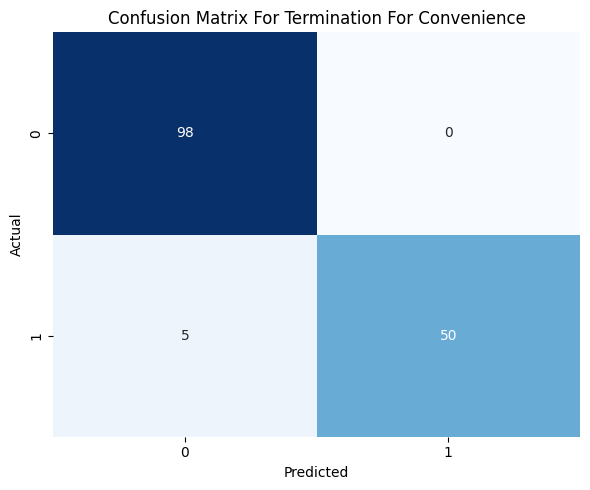

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(eval_df["Actual"], eval_df["Predicted"])

# Plot with seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(eval_df["Actual"]),
            yticklabels=np.unique(eval_df["Actual"]))

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For Termination For Convenience")
plt.tight_layout()
plt.show()


The confusion matrix summarizes rule performance by showing true negatives, false positives, false negatives, and true positives. This provides a complete view of detection outcomes. In this case, the matrix shows zero false positives and some false negatives, suggesting the rules are highly precise but may miss on  `Termination For Convenience` clause variations.

#Task 4: Multi-Clause Automation

After validating the rule-generation process on a single clause, this workflow is intended to generalized into reusable functions to enable scalable rule creation across multiple clauses. Each clause would undergo the same pipeline: example extraction, linguistic pattern discovery using spaCy, regex suggestion generation, and rule evaluation. This ensures methodological consistency across clauses and supports reproducible rule-based detection at scale.

## Defining The Target Clauses

In [ ]:
target_clauses = [
    "Anti-Assignment",
    "Cap On Liability",
    "Termination For Convenience",
    "Exclusivity",
    "Minimum Commitment",
    "Audit Rights",
    "Ip Ownership Assignment",
    "Post-Termination Services",
    "Non-Compete",
    "Uncapped Liability",
    "Revenue/Profit Sharing",
    "License Grant",
    "Change Of Control",
    "Liquidated Damages",
    "Rofr/Rofo/Rofn",
    "Insurance",
    "Volume Restriction",
    "Competitive Restriction Exception",
    "Irrevocable Or Perpetual License",
    "Non-Transferable License",
    "Affiliate License-Licensee",
    "No-Solicit Of Employees",
    "Covenant Not To Sue",
    "Warranty Duration",
    "No-Solicit Of Customers",
    "Affiliate License-Licensor",
    "Joint Ip Ownership",
    "Non-Disparagement"
]

In [ ]:
len(target_clauses)

28

The target clauses represent the highest-priority risks selected from the risk-weighted ranking generated in Task 1. These clauses combine high frequency and significant legal impact for SMEs and startups, making them suitable for the first version of the rule-based detection system. Limiting the scope to a defined set of clauses ensures manageable development, consistent evaluation, and focused rule engineering before scaling to all clause categories.

##Extract Examples

In [ ]:
def get_clause_examples(train_df, clause):
    return train_df[train_df[f"{clause}-Answer"] == "Yes"][clause]


This function extracts clause text samples from the dataset where the clause is labeled as present (“Yes”). These examples serve as the real corpus used for linguistic pattern discovery. By relying only on labeled positive examples, the rule-generation process remains grounded in authentic legal language rather than manually constructed assumptions.

##Generate Verb–Phrase Frequencies

In [ ]:
def get_verb_phrase_freq(texts, nlp):

    verb_phrase_pairs = []

    for text in texts:

        doc = nlp(str(text))

        for token in doc:
            if token.pos_ == "VERB":

                for chunk in doc.noun_chunks:
                    if abs(token.i - chunk.root.i) < 6:

                        pair = (
                            token.lemma_.lower(),
                            chunk.text.lower()
                        )

                        verb_phrase_pairs.append(pair)

    return Counter(verb_phrase_pairs)


This step identifies recurring verb–phrase relationships within clause examples using spaCy’s linguistic parsing capabilities. Legal clauses are often structured around actions (verbs) combined with contextual phrases, such as “terminate + written notice.” Counting these patterns reveals high-frequency linguistic structures that serve as strong indicators for clause detection and later regex generation.

##Generate Regex Suggestions

In [ ]:
def generate_regex_suggestions(pair_freq, top_n=10):

    regex_suggestions = []

    for (verb, phrase), count in pair_freq.most_common(top_n):
        # Escape special regex characters in the phrase and verb
        escaped_phrase_parts = [re.escape(part) for part in phrase.split()]
        phrase_regex = ".*".join(escaped_phrase_parts)

        escaped_verb = re.escape(verb)
        pattern = f"{escaped_verb}.*{phrase_regex}"

        regex_suggestions.append(pattern)

    return regex_suggestions

Frequent verb–phrase patterns are automatically transformed into candidate regex rules. Spaces within phrases are replaced with flexible wildcard matching (.*) to allow variation in legal wording. Regex escaping is applied to ensure that special characters are interpreted safely. These automatically generated patterns form the initial rule candidates, which are later reviewed and refined for reliability.

##Automate For All Clauses

In [ ]:
all_regex_rules = {}

for clause in target_clauses:

    print(f"Processing: {clause}")

    # extract examples
    examples = get_clause_examples(train_df, clause)

    texts = [clean_text(t) for t in examples]

    # verb–phrase discovery
    pair_freq = get_verb_phrase_freq(texts, nlp)

    # regex generation
    regex_suggestions = generate_regex_suggestions(pair_freq)

    # store rules
    all_regex_rules[clause] = regex_suggestions

Processing: Anti-Assignment
Processing: Cap On Liability
Processing: Termination For Convenience
Processing: Exclusivity
Processing: Minimum Commitment
Processing: Audit Rights
Processing: Ip Ownership Assignment
Processing: Post-Termination Services
Processing: Non-Compete
Processing: Uncapped Liability
Processing: Revenue/Profit Sharing
Processing: License Grant
Processing: Change Of Control
Processing: Liquidated Damages
Processing: Rofr/Rofo/Rofn
Processing: Insurance
Processing: Volume Restriction
Processing: Competitive Restriction Exception
Processing: Irrevocable Or Perpetual License
Processing: Non-Transferable License
Processing: Affiliate License-Licensee
Processing: No-Solicit Of Employees
Processing: Covenant Not To Sue
Processing: Warranty Duration
Processing: No-Solicit Of Customers
Processing: Affiliate License-Licensor
Processing: Joint Ip Ownership
Processing: Non-Disparagement


The rule-generation workflow is automated across all target clauses to ensure consistency and scalability. For each clause, the pipeline performs example extraction, linguistic pattern discovery, and regex suggestion generation. The resulting patterns are stored in a centralized rule dictionary, enabling efficient reuse during detection and evaluation while minimizing manual rule creation.

In [ ]:
all_regex_rules['Rofr/Rofo/Rofn']

['write.*written.*notice',
 'have.*the.*right',
 'provide.*written.*notice',
 'enter.*an.*agreement',
 'negotiate.*good.*faith',
 'exercise.*its.*option',
 'include.*which',
 'provide.*bii',
 'write.*it',
 'set.*section']

In [ ]:
all_regex_rules['Exclusivity']

['have.*the.*exclusive.*right',
 'sell.*market',
 'offer.*sale',
 'set.*this.*agreement',
 'sublicense.*the.*right',
 'include.*limitation',
 'grant.*the.*right',
 'grant.*sublicenses',
 'set.*the.*terms',
 'sell.*the.*exclusive.*right']

In [ ]:
all_regex_rules['Affiliate License-Licensor']

['grant.*the.*right',
 'grant.*sublicenses',
 'control.*that',
 'use.*the.*effective.*date',
 'use.*use',
 'hold.*the.*effective.*date',
 'hold.*use',
 'perform.*\\*',
 'make.*use',
 'have.*the.*right']

In [ ]:
all_regex_rules['Warranty Duration']

['write.*written.*notice',
 'write.*written.*notification',
 'meet.*the.*specifications',
 'have.*the.*right',
 'provide.*dexcel',
 'provide.*written.*notification',
 'write.*dexcel',
 'perform.*accordance',
 'deem.*bellicum',
 'accept.*miltenyi.*products']

##Run Evaluation for ALL Clauses

In [ ]:
def evaluate_clause(test_df, clause, patterns):

    eval_df = test_df.copy()

    # Predictions
    eval_df["Predicted"] = eval_df[clause].apply(
        lambda x: detect_clause(x, patterns)
    )

    # Ground Truth
    eval_df["Actual"] = eval_df[f"{clause}-Answer"].apply(
        lambda x: 1 if x == "Yes" else 0
    )

    # Confusion matrix with fixed labels
    tn, fp, fn, tp = confusion_matrix(
        eval_df["Actual"],
        eval_df["Predicted"],
        labels=[0, 1]
    ).ravel()

    # Metrics
    precision = precision_score(eval_df["Actual"], eval_df["Predicted"], zero_division=0)
    recall = recall_score(eval_df["Actual"], eval_df["Predicted"], zero_division=0)

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    if (precision + recall) == 0:
        f1 = 0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    coverage = eval_df["Predicted"].mean()

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Accuracy": round(accuracy, 4),
        "F1-Score": round(f1, 4),
        "Coverage": round(coverage, 4)
    }

This function evaluates rule performance by comparing rule-based predictions against CUAD’s labeled ground truth. Precision measures the accuracy of detected clauses, recall measures the proportion of true clauses successfully identified, and coverage indicates how frequently rules activate across the dataset. These metrics provide quantitative evidence of rule effectiveness and guide future refinement.

In [ ]:

results = []

for clause in target_clauses:

    patterns = all_regex_rules[clause]

    metrics = evaluate_clause(test_df, clause, patterns)

    results.append({
        "Clause": clause,
        "TP": metrics["TP"],
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Coverage": metrics["Coverage"]
    })

results_df = pd.DataFrame(results)

print(results_df)

                               Clause  TP   TN  FP  FN  Precision  Recall  \
0                     Anti-Assignment  93   48   0  12        1.0  0.8857   
1                    Cap On Liability  48   78   0  27        1.0  0.6400   
2         Termination For Convenience  50   98   0   5        1.0  0.9091   
3                         Exclusivity  28   95   0  30        1.0  0.4828   
4                  Minimum Commitment  16  100   0  37        1.0  0.3019   
5                        Audit Rights  41   95   0  17        1.0  0.7069   
6             Ip Ownership Assignment  28  119   0   6        1.0  0.8235   
7           Post-Termination Services  25  102   0  26        1.0  0.4902   
8                         Non-Compete  16  119   0  18        1.0  0.4706   
9                  Uncapped Liability  20  123   0  10        1.0  0.6667   
10             Revenue/Profit Sharing  21   99   0  33        1.0  0.3889   
11                      License Grant  63   77   0  13        1.0  0.8289   

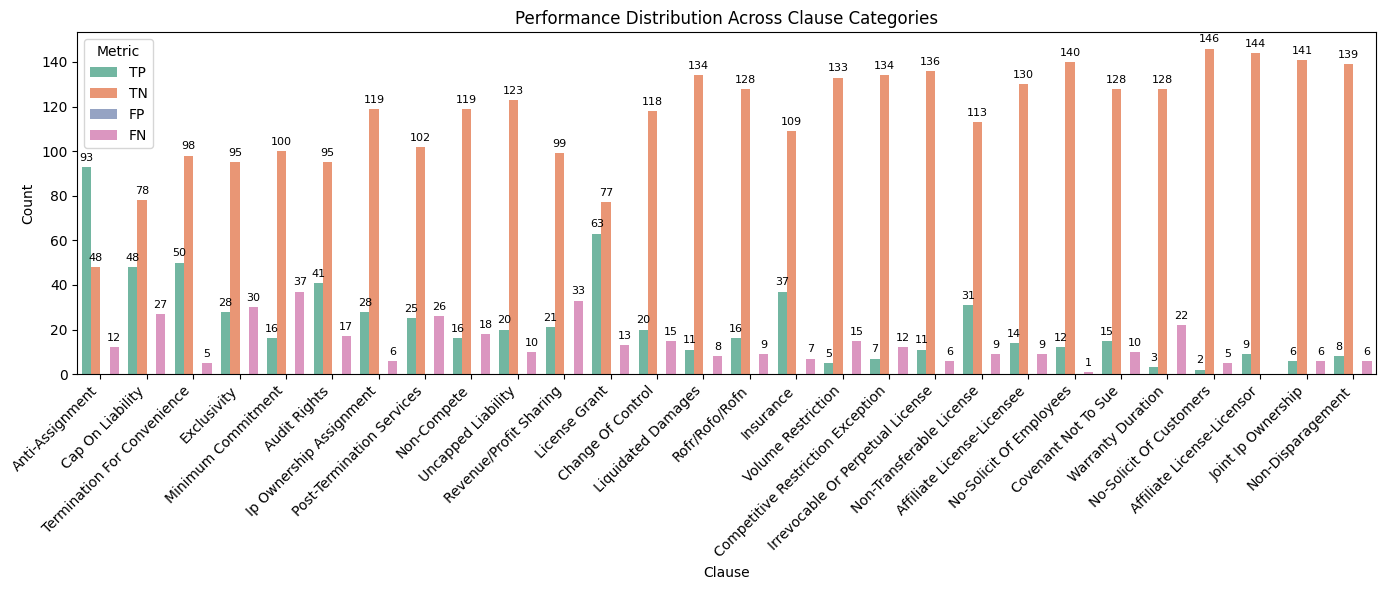

In [ ]:
# Melt the dataframe to long format for easier plotting
cm_df = results_df.melt(
    id_vars=["Clause"],
    value_vars=["TP", "TN", "FP", "FN"],
    var_name="Metric",
    value_name="Count"
)

# Plot grouped bar chart
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=cm_df, x="Clause", y="Count", hue="Metric", palette="Set2")

# Add annotations
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only annotate non-zero bars
        ax.annotate(f'{height:.0f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points',
                    fontsize=8)

# Formatting
plt.title("Performance Distribution Across Clause Categories")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.xlabel("Clause")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

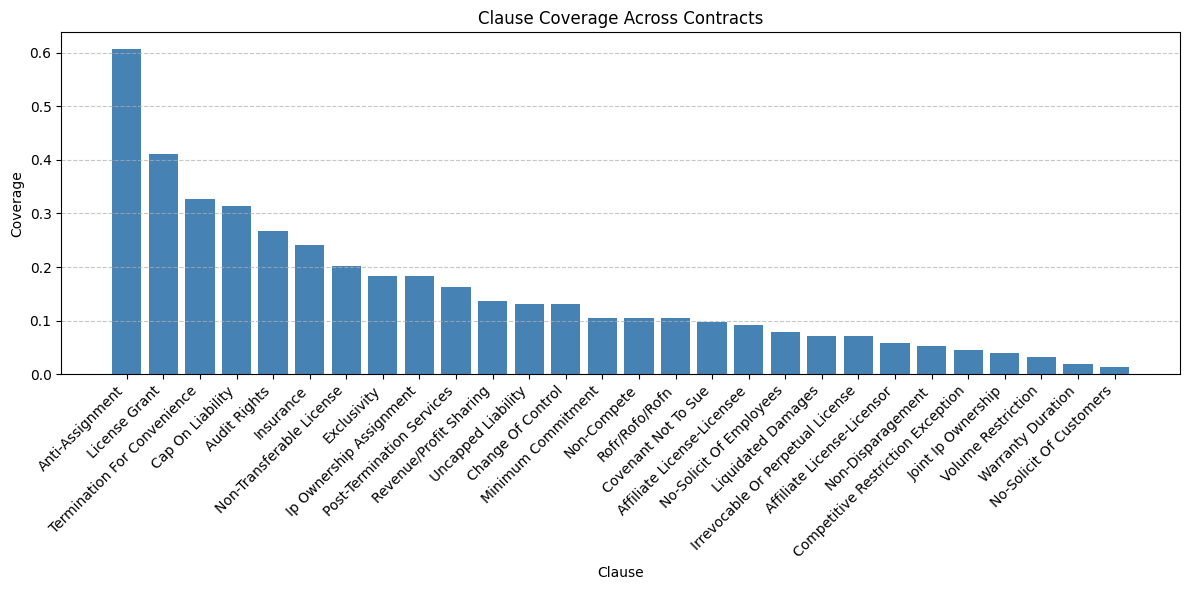

In [ ]:
# Sort clauses by coverage for better visual clarity
sorted_df = results_df.sort_values(by="Coverage", ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(sorted_df["Clause"], sorted_df["Coverage"], color='steelblue')
plt.xlabel("Clause")
plt.ylabel("Coverage")
plt.title("Clause Coverage Across Contracts")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

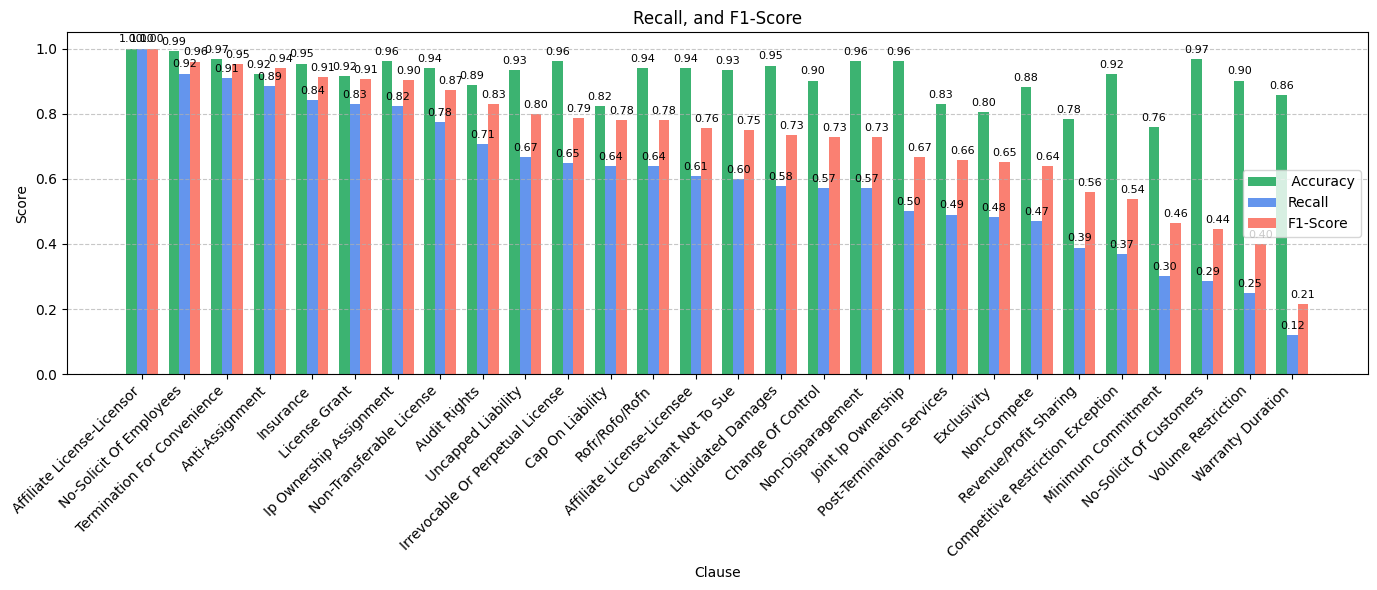

In [ ]:
# Sort clauses for consistent display
sorted_df = results_df.sort_values(by="F1-Score", ascending=False)

# Extract values
clauses = sorted_df["Clause"]
precision = sorted_df["Precision"]
recall = sorted_df["Recall"]
f1_score = sorted_df["F1-Score"]
Accuracy = sorted_df["Accuracy"]
# Set bar width and positions
bar_width = 0.25
x = np.arange(len(clauses))

# Plotting
plt.figure(figsize=(14, 6))
bars_Accuracy = plt.bar(x - bar_width,  Accuracy, width=bar_width, label=' Accuracy', color='mediumseagreen')
bars_recall = plt.bar(x, recall, width=bar_width, label='Recall', color='cornflowerblue')
bars_f1 = plt.bar(x + bar_width, f1_score, width=bar_width, label='F1-Score', color='salmon')

# Add annotations (numeric values above bars)
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # offset above bar
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

annotate_bars(bars_Accuracy)
annotate_bars(bars_recall)
annotate_bars(bars_f1)

# Formatting
plt.xlabel("Clause")
plt.ylabel("Score")
plt.title("Recall, and F1-Score")
plt.xticks(x, clauses, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Task 5: RULE LEARNING & EXTRACTION (Hybrid Rule Engine)

In this section, we extend the initial verb–noun phrase rule by introducing a hybrid, data-driven rule learning approach.
Instead of relying solely on manually defined patterns, we automatically extract rule candidates from the training dataset. These rules are derived using multiple techniques, including:

- Verb–noun phrase pattern extraction
- TF-IDF-based keyword learning

Each rule type captures different linguistic signals in contractual clauses, improving the system’s ability to detect implicit and explicit risk patterns.
All rules are learned exclusively from the training dataset to avoid data leakage and ensure fair evaluation.

In [ ]:
all_keyword_rules = {}

for clause in target_clauses:

    print(f"Processing TF-IDF for: {clause}")

    examples = get_clause_examples(train_df, clause)

    texts = [clean_text(t) for t in examples]

    # handle edge case
    if len(texts) == 0:
        all_keyword_rules[clause] = []
        continue

    vectorizer = TfidfVectorizer(
        ngram_range=(1,2),
        stop_words='english'
    )

    X = vectorizer.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).flatten()

    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = terms[scores.argsort()[-15:]]

    all_keyword_rules[clause] = list(top_terms)

Processing TF-IDF for: Anti-Assignment
Processing TF-IDF for: Cap On Liability
Processing TF-IDF for: Termination For Convenience
Processing TF-IDF for: Exclusivity
Processing TF-IDF for: Minimum Commitment
Processing TF-IDF for: Audit Rights
Processing TF-IDF for: Ip Ownership Assignment
Processing TF-IDF for: Post-Termination Services
Processing TF-IDF for: Non-Compete
Processing TF-IDF for: Uncapped Liability
Processing TF-IDF for: Revenue/Profit Sharing
Processing TF-IDF for: License Grant
Processing TF-IDF for: Change Of Control
Processing TF-IDF for: Liquidated Damages
Processing TF-IDF for: Rofr/Rofo/Rofn
Processing TF-IDF for: Insurance
Processing TF-IDF for: Volume Restriction
Processing TF-IDF for: Competitive Restriction Exception
Processing TF-IDF for: Irrevocable Or Perpetual License
Processing TF-IDF for: Non-Transferable License
Processing TF-IDF for: Affiliate License-Licensee
Processing TF-IDF for: No-Solicit Of Employees
Processing TF-IDF for: Covenant Not To Sue
Proc

To improve detection performance, we combine multiple rule types into a unified hybrid rule structure.

Each clause category is associated with:
- Regex patterns (from verb–noun extraction)
- Keyword patterns (from TF-IDF learning)

This hybrid structure enables the system to capture both syntactic and semantic signals.

In [ ]:
all_keyword_rules['Rofr/Rofo/Rofn']

['patent',
 'period',
 'new',
 'terms',
 'days',
 'licensee',
 'product',
 'option',
 'purchase',
 'offer',
 'agreement',
 'right',
 'party',
 'notice',
 'shall']

In [ ]:
all_keyword_rules['Exclusivity']

['subject',
 'services',
 'term',
 'party',
 'company',
 'use',
 'territory',
 'right',
 'license',
 'products',
 'product',
 'distributor',
 'shall',
 'exclusive',
 'agreement']

In [ ]:
all_keyword_rules['Affiliate License-Licensor']

['grants',
 'non',
 'product',
 'section',
 'data',
 'license',
 'right',
 'agreement',
 'company',
 'xencor',
 'affiliates',
 'patents',
 'use',
 'licensed',
 'products']

In [ ]:
all_keyword_regex_rules = {}

for clause in target_clauses:

    keywords = all_keyword_rules.get(clause, [])

    keyword_regex = [
        rf"\b{re.escape(keyword)}\b"
        for keyword in keywords
    ]

    all_keyword_regex_rules[clause] = keyword_regex

In [ ]:
results_keyword = []

for clause in target_clauses:

    patterns = all_keyword_regex_rules[clause]

    metrics = evaluate_clause(test_df, clause, patterns)

    results_keyword.append({
        "Clause": clause,
        "TP": metrics["TP"],
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Coverage": metrics["Coverage"]
    })

results_keyword_df = pd.DataFrame(results_keyword)

print(results_keyword_df)

                               Clause   TP   TN  FP  FN  Precision  Recall  \
0                     Anti-Assignment  105   48   0   0        1.0  1.0000   
1                    Cap On Liability   75   78   0   0        1.0  1.0000   
2         Termination For Convenience   55   98   0   0        1.0  1.0000   
3                         Exclusivity   58   95   0   0        1.0  1.0000   
4                  Minimum Commitment   53  100   0   0        1.0  1.0000   
5                        Audit Rights   58   95   0   0        1.0  1.0000   
6             Ip Ownership Assignment   34  119   0   0        1.0  1.0000   
7           Post-Termination Services   51  102   0   0        1.0  1.0000   
8                         Non-Compete   34  119   0   0        1.0  1.0000   
9                  Uncapped Liability   30  123   0   0        1.0  1.0000   
10             Revenue/Profit Sharing   53   99   0   1        1.0  0.9815   
11                      License Grant   76   77   0   0        1

In [ ]:
hybrid_rules = {}

for clause in target_clauses:
    hybrid_rules[clause] = {
        "regex": all_regex_rules.get(clause, []),
        "keywords": all_keyword_rules.get(clause, [])
    }

In [ ]:
hybrid_rules['Rofr/Rofo/Rofn']

{'regex': ['write.*written.*notice',
  'have.*the.*right',
  'provide.*written.*notice',
  'enter.*an.*agreement',
  'negotiate.*good.*faith',
  'exercise.*its.*option',
  'include.*which',
  'provide.*bii',
  'write.*it',
  'set.*section'],
 'keywords': ['patent',
  'period',
  'new',
  'terms',
  'days',
  'licensee',
  'product',
  'option',
  'purchase',
  'offer',
  'agreement',
  'right',
  'party',
  'notice',
  'shall']}

In [ ]:
hybrid_rules['Exclusivity']

{'regex': ['have.*the.*exclusive.*right',
  'sell.*market',
  'offer.*sale',
  'set.*this.*agreement',
  'sublicense.*the.*right',
  'include.*limitation',
  'grant.*the.*right',
  'grant.*sublicenses',
  'set.*the.*terms',
  'sell.*the.*exclusive.*right'],
 'keywords': ['subject',
  'services',
  'term',
  'party',
  'company',
  'use',
  'territory',
  'right',
  'license',
  'products',
  'product',
  'distributor',
  'shall',
  'exclusive',
  'agreement']}

In [ ]:
all_hybrid_regex_rules = {}

for clause in target_clauses:

    regex_patterns = all_regex_rules.get(clause, [])
    keyword_patterns = all_keyword_rules.get(clause, [])

    keyword_regex = [
        rf"\b{re.escape(keyword)}\b"
        for keyword in keyword_patterns
    ]

    combined_patterns = regex_patterns + keyword_regex

    all_hybrid_regex_rules[clause] = combined_patterns

To support hybrid rule detection, TF-IDF keyword rules are converted into regex-compatible patterns and merged with the previously generated verb–noun regex rules.

This transformation ensures that all rule types follow a unified structure, allowing the detection engine to operate without modification while benefiting from both syntactic and semantic signals.

In [ ]:
results_hybrid = []

for clause in target_clauses:

    patterns = all_hybrid_regex_rules[clause]

    metrics = evaluate_clause(test_df, clause, patterns)

    results_hybrid.append({
        "Clause": clause,
        "TP": metrics["TP"],
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Coverage": metrics["Coverage"]
    })

results_hybrid_df = pd.DataFrame(results_hybrid)

print(results_hybrid_df)

                               Clause   TP   TN  FP  FN  Precision  Recall  \
0                     Anti-Assignment  105   48   0   0        1.0  1.0000   
1                    Cap On Liability   75   78   0   0        1.0  1.0000   
2         Termination For Convenience   55   98   0   0        1.0  1.0000   
3                         Exclusivity   58   95   0   0        1.0  1.0000   
4                  Minimum Commitment   53  100   0   0        1.0  1.0000   
5                        Audit Rights   58   95   0   0        1.0  1.0000   
6             Ip Ownership Assignment   34  119   0   0        1.0  1.0000   
7           Post-Termination Services   51  102   0   0        1.0  1.0000   
8                         Non-Compete   34  119   0   0        1.0  1.0000   
9                  Uncapped Liability   30  123   0   0        1.0  1.0000   
10             Revenue/Profit Sharing   53   99   0   1        1.0  0.9815   
11                      License Grant   76   77   0   0        1

#Task 6: MODEL PACKAGING

This stage transitions the project from research experimentation into a deployable decision-support engine. Instead of keeping rules and logic inside exploratory notebooks, the model components are exported into reusable artifacts that other development teams can integrate into applications.

The system uses a hybrid rule approach combining:
- Regex patterns (from verb–noun extraction)
- TF-IDF keyword patterns

To maintain compatibility with the detection engine, all rule types are converted into a unified regex format before export. This ensures that the deployment pipeline remains simple, scalable, and efficient.

##Exporting The Regex Rules

In [ ]:
save_path = "/content/drive/MyDrive/SPL 2.0"

with open(f"{save_path}/rules.json", "w") as f:
    json.dump(all_regex_rules, f, indent=2)

with open(f"{save_path}/hybrid_rules.json", "w") as f:
    json.dump(all_hybrid_regex_rules, f, indent=2)

**Both the regex rule and hybrid rule set is exported as a JSON file, enabling external systems to load and apply clause detection logic without relying on notebook execution. This decouples the rule engine from the development environment and supports scalable deployment.

##Exporting The Severity Mapping

In [ ]:
with open(f"{save_path}/severity_mapping.json", "w") as f:
    json.dump(severity_mapping, f, indent=2)

Severity mappings are exported as a standalone resource so that risk prioritization can be applied consistently across platforms. This enables the user interface to display meaningful warnings based on predefined risk levels.

##Create Clause Into Domain Lookup

In [ ]:
# Build clause → domain lookup
clause_to_domain = {}

for domain, clauses in risk_domain_mapping.items():
    for c in clauses:
        clause_to_domain[c] = domain


The risk taxonomy is reversed to create a clause-to-domain lookup dictionary. This transformation allows the system to quickly identify the broader risk category associated with each detected clause during runtime.

In [ ]:
clause_to_domain

{'Uncapped Liability': 'Financial Risk',
 'Cap On Liability': 'Financial Risk',
 'Liquidated Damages': 'Financial Risk',
 'Minimum Commitment': 'Financial Risk',
 'Revenue/Profit Sharing': 'Financial Risk',
 'Price Restrictions': 'Financial Risk',
 'Most Favored Nation': 'Financial Risk',
 'Volume Restriction': 'Financial Risk',
 'Termination For Convenience': 'Operational Risk',
 'Post-Termination Services': 'Operational Risk',
 'Audit Rights': 'Operational Risk',
 'Anti-Assignment': 'Operational Risk',
 'Change Of Control': 'Operational Risk',
 'Renewal Term': 'Operational Risk',
 'Non-Compete': 'Strategic Restriction Risk',
 'Exclusivity': 'Strategic Restriction Risk',
 'No-Solicit Of Employees': 'Strategic Restriction Risk',
 'No-Solicit Of Customers': 'Strategic Restriction Risk',
 'Competitive Restriction Exception': 'Strategic Restriction Risk',
 'Rofr/Rofo/Rofn': 'Strategic Restriction Risk',
 'Ip Ownership Assignment': 'Intellectual Property Risk',
 'Joint Ip Ownership': 'Inte

##Create Severity Templates

In [ ]:
severity_templates = {
    "High": "This clause may significantly affect your rights or obligations.",
    "Medium": "This clause may require attention depending on your situation.",
    "Low": "This clause is generally informational but still important to review."
}


Severity templates define standardized explanation styles for each risk level. These templates ensure that generated user warnings are consistent, interpretable, and aligned with the system’s transparency objectives.

##Auto-generate Messages

In [ ]:
warning_messages = {}

for clause in target_clauses:

    severity = severity_mapping.get(clause, "Low")
    domain = clause_to_domain.get(clause, "General Risk")

    warning_messages[clause] = (
    f"{severity_templates[severity]} "
    f"This relates to {domain.lower()}."
)


User-facing warning messages are generated automatically using clause severity and risk domain information. This avoids manual hardcoding and ensures scalability as additional clauses or risk categories are introduced.

##Exporting The Warning  Messages JSON file

In [ ]:
with open(f"{save_path}/warning_messages.json", "w") as f:
    json.dump(warning_messages, f, indent=2)

##Analyze Agreement Function

In [ ]:
def traffic_light(severity):
    if severity == "High":
        return "red"
    elif severity == "Medium":
        return "yellow"
    else:
        return "green"


def analyze_agreement(text, rules, severity_mapping, warning_messages):

    text = str(text).lower()
    flags = []

    for clause, patterns in rules.items():

        for pattern in patterns:

            if re.search(pattern, text):

                severity = severity_mapping.get(clause, "Low")

                flags.append({
                    "clause": clause,
                    "severity": severity,
                    "traffic_light": traffic_light(severity),
                    "message": warning_messages.get(clause, "")
                })

                break

    # --- Overall Risk Summary ---
    high_count = sum(1 for f in flags if f["severity"] == "High")
    medium_count = sum(1 for f in flags if f["severity"] == "Medium")

    if high_count > 0:
        overall_risk = "High"
        summary = f"{high_count} high-risk clause(s) detected."
    elif medium_count > 0:
        overall_risk = "Medium"
        summary = f"{medium_count} medium-risk clause(s) detected."
    else:
        overall_risk = "Low"
        summary = "No major risk clauses detected."

    return {
        "flags": flags,
        "overall_risk": overall_risk,
        "summary": summary
    }

The analyze_agreement() function represents the core decision engine of the system. It processes agreement text, applies hybrid rule-based clause detection, assigns severity levels, and generates user-facing explanations.

By using a unified regex-based rule format, the function seamlessly integrates both syntactic (regex) and semantic (keyword-derived) signals without requiring additional processing layers.

The function outputs structured JSON-ready results that can be directly consumed by mobile or web applications.

#Overall Risk Summary

The overall risk summary is computed by aggregating detected clause severities. This provides users with a quick high-level assessment before reviewing individual warnings, reducing cognitive load and supporting faster decision-making.